# AEGES-Q: QML Training and Evaluation

This notebook implements the actual quantum machine learning experiment
for the AEGES-Q cybersecurity framework.

The purpose is to train and evaluate a quantum machine learning classifier
using the UNSW-NB15 dataset.

The quantum model will be compared against the existing classical
Random Forest baseline using the same dataset split.

The comparison will consider:

1. Accuracy
2. Precision
3. Recall
4. F1-score
5. ROC-AUC
6. False-positive rate
7. Training time
8. Inference time
9. Circuit depth
10. Number of qubits

The final objective is to determine whether the quantum model is suitable
for integration into the adaptive AEGES-Q framework.

## 1. Environment Verification

This section verifies that the notebook is using the correct project
virtual environment and that all required quantum machine learning
libraries are available.

The experiments will initially run locally using the Qiskit Aer simulator.
No physical quantum computer is required for this stage.

In [2]:
import sys
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qiskit
import qiskit_aer

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.circuit import ParameterVector

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nQiskit version:")
print(qiskit.__version__)

print("\nQiskit Aer version:")
print(qiskit_aer.__version__)

print("\nQiskit Machine Learning version:")
print(version("qiskit-machine-learning"))

simulator = AerSimulator()

print("\nAer simulator initialized successfully.")

Python executable:
c:\Projects\Aeges-Q\.venv\Scripts\python.exe

Python version:
3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]

Qiskit version:
2.5.2

Qiskit Aer version:
0.17.2

Qiskit Machine Learning version:
0.9.1

Aer simulator initialized successfully.


## 2. Locate the Existing UNSW-NB15 Dataset

The classical machine learning pipeline has already been completed.

This notebook will reuse the existing dataset and preprocessing outputs
instead of creating a separate preprocessing pipeline.

This is important because the quantum and classical models must be evaluated
on the same data split for a fair comparison.

The first step is to identify the existing dataset files inside the project.

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]

# Only show likely data/model files, excluding notebooks and cache folders
allowed_extensions = {
    ".csv", ".parquet", ".pkl", ".joblib", ".json", ".xlsx", ".npy", ".npz"
}

excluded_parts = {
    ".git",
    ".venv",
    "__pycache__",
    ".ipynb_checkpoints",
}

print("Project root:")
print(PROJECT_ROOT)

print("\nPossible dataset/model files:")

matches = []

for path in PROJECT_ROOT.rglob("*"):
    if not path.is_file():
        continue

    if path.suffix.lower() not in allowed_extensions:
        continue

    if any(part in excluded_parts for part in path.parts):
        continue

    matches.append(path)

for path in sorted(matches):
    print(path.relative_to(PROJECT_ROOT))

print(f"\nTotal matching files: {len(matches)}")

Project root:
c:\Projects\Aeges-Q

Possible dataset/model files:
artifacts\classical\random_forest.joblib
artifacts\classical\variant_e_preprocessor.joblib
data\raw\NUSW-NB15_features.csv
data\raw\UNSW-NB15_1.csv
data\raw\UNSW-NB15_2.csv
data\raw\UNSW-NB15_3.csv
data\raw\UNSW-NB15_4.csv
data\raw\UNSW-NB15_LIST_EVENTS.csv
data\raw\UNSW_NB15_testing-set.csv
data\raw\UNSW_NB15_training-set.csv

Total matching files: 10


## 3. Load Existing Dataset and Classical Artifacts

The classical IDS pipeline has already been trained and evaluated.

This notebook reuses the existing UNSW-NB15 training and testing datasets, preprocessing artifact, and Random Forest model so that the quantum model can be evaluated against the same baseline.

In [4]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parents[1]

TRAIN_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "UNSW_NB15_training-set.csv"
)

TEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "UNSW_NB15_testing-set.csv"
)

PREPROCESSOR_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "classical"
    / "variant_e_preprocessor.joblib"
)

RF_MODEL_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "classical"
    / "random_forest.joblib"
)

print("Training dataset:", TRAIN_PATH.exists())
print("Testing dataset:", TEST_PATH.exists())
print("Preprocessor:", PREPROCESSOR_PATH.exists())
print("Random Forest:", RF_MODEL_PATH.exists())

Training dataset: True
Testing dataset: True
Preprocessor: True
Random Forest: True


In [5]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

preprocessor = joblib.load(PREPROCESSOR_PATH)
random_forest = joblib.load(RF_MODEL_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
print("Preprocessor:", type(preprocessor).__name__)
print("Random Forest:", type(random_forest).__name__)

Training shape: (82332, 45)
Testing shape: (175341, 45)
Preprocessor: ColumnTransformer
Random Forest: RandomForestClassifier


## 4. Prepare Quantum-Compatible Dataset

The exploratory data analysis and complete preprocessing pipeline were already performed during the classical IDS implementation.

For the initial QML experiment, a reduced four-feature dataset is created. Four features are selected because each feature will be encoded into one qubit using a rotation angle.

The same training and testing split is retained to ensure a fair comparison with the existing classical Random Forest model.

In [6]:
# Inspect the existing preprocessing pipeline
print("Preprocessor type:", type(preprocessor).__name__)

print("\nPreprocessor transformers:")
for name, transformer, columns in preprocessor.transformers_:
    print(f"\n{name}:")
    print("Transformer:", type(transformer).__name__)
    print("Number of columns:", len(columns))
    print("Columns:", list(columns))

Preprocessor type: ColumnTransformer

Preprocessor transformers:

numeric:
Transformer: Pipeline
Number of columns: 26
Columns: ['dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_state_ttl', 'ct_dst_sport_ltm', 'ct_srv_dst', 'is_ftp_login', 'ct_flw_http_mthd']

categorical:
Transformer: Pipeline
Number of columns: 3
Columns: ['proto', 'service', 'state']


## 4.1 Select Four Numerical Features

In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Four numerical features for the first QML experiment
QUANTUM_FEATURES = ["dur", "sbytes", "dbytes", "rate"]
TARGET_COLUMN = "label"

# Confirm required columns exist
missing_train = [
    col for col in QUANTUM_FEATURES + [TARGET_COLUMN]
    if col not in train_df.columns
]

missing_test = [
    col for col in QUANTUM_FEATURES + [TARGET_COLUMN]
    if col not in test_df.columns
]

print("Missing columns in training data:", missing_train)
print("Missing columns in testing data:", missing_test)

# Extract selected features and labels
X_train_raw = train_df[QUANTUM_FEATURES].copy()
X_test_raw = test_df[QUANTUM_FEATURES].copy()

y_train = train_df[TARGET_COLUMN].astype(int).to_numpy()
y_test = test_df[TARGET_COLUMN].astype(int).to_numpy()

print("Training feature shape:", X_train_raw.shape)
print("Testing feature shape:", X_test_raw.shape)
print("Training labels:", np.bincount(y_train))
print("Testing labels:", np.bincount(y_test))

Missing columns in training data: []
Missing columns in testing data: []
Training feature shape: (82332, 4)
Testing feature shape: (175341, 4)
Training labels: [37000 45332]
Testing labels: [ 56000 119341]


## 4.2 Normalize Features for Quantum Encoding

In [9]:
# Fit the scaler only on training data
quantum_scaler = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = quantum_scaler.fit_transform(X_train_raw)
X_test_scaled = quantum_scaler.transform(X_test_raw)

# Convert normalized values into rotation angles between 0 and pi
X_train_angles = X_train_scaled * np.pi
X_test_angles = X_test_scaled * np.pi

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nFirst training sample:")
print("Raw values:", X_train_raw.iloc[0].to_numpy())
print("Scaled values:", X_train_scaled[0])
print("Quantum angles:", X_train_angles[0])

Scaled training shape: (82332, 4)
Scaled testing shape: (175341, 4)

First training sample:
Raw values: [1.10000000e-05 4.96000000e+02 0.00000000e+00 9.09090902e+04]
Scaled values: [1.83333367e-07 3.28788116e-05 0.00000000e+00 9.09090899e-02]
Quantum angles: [5.75958759e-07 1.03291833e-04 0.00000000e+00 2.85599329e-01]


## 4.3 Create a Small Stratified Quantum Dataset

In [10]:
from sklearn.model_selection import train_test_split

# Small subset for local quantum simulation
QML_TRAIN_SIZE = 2000
QML_TEST_SIZE = 1000

# Stratified training subset
X_qml_train, _, y_qml_train, _ = train_test_split(
    X_train_angles,
    y_train,
    train_size=QML_TRAIN_SIZE,
    stratify=y_train,
    random_state=42
)

# Stratified testing subset
X_qml_test, _, y_qml_test, _ = train_test_split(
    X_test_angles,
    y_test,
    train_size=QML_TEST_SIZE,
    stratify=y_test,
    random_state=42
)

print("QML training shape:", X_qml_train.shape)
print("QML testing shape:", X_qml_test.shape)

print("\nQML training label distribution:")
print(pd.Series(y_qml_train).value_counts().sort_index())

print("\nQML testing label distribution:")
print(pd.Series(y_qml_test).value_counts().sort_index())

QML training shape: (2000, 4)
QML testing shape: (1000, 4)

QML training label distribution:
0     899
1    1101
Name: count, dtype: int64

QML testing label distribution:
0    319
1    681
Name: count, dtype: int64


## 4.4 Visualize the Quantum-Compatible Features

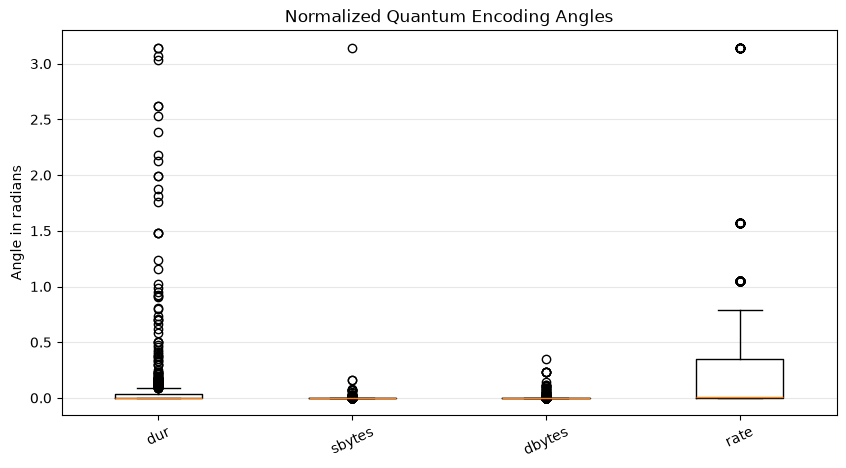

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.boxplot(
    X_qml_train,
    tick_labels=QUANTUM_FEATURES
)

plt.title("Normalized Quantum Encoding Angles")
plt.ylabel("Angle in radians")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 4.5 Inspect One Encoded Sample

In [12]:
sample_index = 0

print("Selected features:", QUANTUM_FEATURES)
print("Encoded angles:", X_qml_train[sample_index])
print("Class label:", y_qml_train[sample_index])

print("\nInterpretation:")
for feature, angle in zip(QUANTUM_FEATURES, X_qml_train[sample_index]):
    print(f"{feature}: rotation angle = {angle:.6f} radians")

Selected features: ['dur', 'sbytes', 'dbytes', 'rate']
Encoded angles: [6.23244973e-03 2.08772052e-04 1.84326384e-05 1.84751443e-04]
Class label: 0

Interpretation:
dur: rotation angle = 0.006232 radians
sbytes: rotation angle = 0.000209 radians
dbytes: rotation angle = 0.000018 radians
rate: rotation angle = 0.000185 radians


### Observation

The selected network features are highly right-skewed. Most samples have small normalized values, while a small number of samples produce large rotation angles.

This is expected in network traffic data because many connections contain very few bytes or packets, whereas a smaller number of connections generate substantially higher traffic.

The MinMaxScaler converts the features into the range [0, 1], and multiplying by π maps them to quantum rotation angles in the range [0, π].

## 5. Build the First QML Classifier
We use four qubits, one for each selected network feature.

Each feature controls a rotation gate:

- `dur` → qubit 0
- `sbytes` → qubit 1
- `dbytes` → qubit 2
- `rate` → qubit 3

The circuit then applies trainable rotations and entangling gates. Finally, the first qubit is measured. Its probability of being in state `1` is used as the model output.

In [14]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

number_of_qubits = 4

# Trainable parameters
theta = ParameterVector("θ", length=8)

def build_qml_circuit(feature_angles):
    """
    Build a four-qubit variational quantum circuit.

    feature_angles:
        Four input rotation angles.
    """
    qc = QuantumCircuit(number_of_qubits, 1)

    # Encode the four classical features
    for qubit in range(number_of_qubits):
        qc.ry(float(feature_angles[qubit]), qubit)

    # Trainable rotation layer
    for qubit in range(number_of_qubits):
        qc.ry(theta[qubit], qubit)

    # Entanglement layer
    for qubit in range(number_of_qubits - 1):
        qc.cx(qubit, qubit + 1)

    # Second trainable layer
    for qubit in range(number_of_qubits):
        qc.rz(theta[qubit + 4], qubit)

    # Measure the first qubit
    qc.measure(0, 0)

    return qc

In [15]:
example_circuit = build_qml_circuit(X_qml_train[0])

print(example_circuit)

     ┌───────────────┐ ┌──────────┐     ┌──────────┐            ┌─┐            
q_0: ┤ Ry(0.0062324) ├─┤ Ry(θ[0]) ├──■──┤ Rz(θ[4]) ├────────────┤M├────────────
     ├───────────────┴┐├──────────┤┌─┴─┐└──────────┘┌──────────┐└╥┘            
q_1: ┤ Ry(0.00020877) ├┤ Ry(θ[1]) ├┤ X ├─────■──────┤ Rz(θ[5]) ├─╫─────────────
     ├────────────────┤├──────────┤└───┘   ┌─┴─┐    └──────────┘ ║ ┌──────────┐
q_2: ┤ Ry(1.8433e-05) ├┤ Ry(θ[2]) ├────────┤ X ├─────────■───────╫─┤ Rz(θ[6]) ├
     ├────────────────┤├──────────┤        └───┘       ┌─┴─┐     ║ ├──────────┤
q_3: ┤ Ry(0.00018475) ├┤ Ry(θ[3]) ├────────────────────┤ X ├─────╫─┤ Rz(θ[7]) ├
     └────────────────┘└──────────┘                    └───┘     ║ └──────────┘
c: 1/════════════════════════════════════════════════════════════╩═════════════
                                                                 0             


## 5.1 Run the Variational Circuit

In [16]:
from qiskit_aer import AerSimulator
import numpy as np

simulator = AerSimulator()

# Initial values for the trainable parameters
initial_parameters = {
    theta[0]: 0.1,
    theta[1]: 0.2,
    theta[2]: 0.3,
    theta[3]: 0.4,
    theta[4]: 0.1,
    theta[5]: 0.2,
    theta[6]: 0.3,
    theta[7]: 0.4,
}

# Use the first QML training sample
sample_angles = X_qml_train[0]

# Build and bind the circuit
sample_circuit = build_qml_circuit(sample_angles)
bound_circuit = sample_circuit.assign_parameters(initial_parameters)

# Run the circuit
job = simulator.run(bound_circuit, shots=1000)
result = job.result()
counts = result.get_counts()

print("Measurement counts:", counts)

Measurement counts: {'0': 998, '1': 2}


## 5.2 Convert Measurement Counts into a Prediction Probability

In [17]:
def probability_of_one(counts):
    """
    Calculate the probability of measuring the output qubit as 1.
    """
    total_shots = sum(counts.values())
    one_count = counts.get("1", 0)

    return one_count / total_shots


probability_attack = probability_of_one(counts)

print(f"Probability of attack: {probability_attack:.4f}")
print(f"Probability of normal traffic: {1 - probability_attack:.4f}")

Probability of attack: 0.0020
Probability of normal traffic: 0.9980


## 5.3 Convert Probability into a Binary Prediction

In [18]:
# Classification threshold
threshold = 0.5

predicted_label = int(probability_attack >= threshold)

print("Predicted label:", predicted_label)
print("Actual label:", y_qml_train[0])

if predicted_label == 1:
    print("Prediction: Attack")
else:
    print("Prediction: Normal")

Predicted label: 0
Actual label: 0
Prediction: Normal


## 5.4 Create a Quantum Prediction Function

In [19]:
def quantum_predict_probability(feature_angles, parameters, shots=256):
    """
    Run the quantum circuit for one sample and return
    the probability of the attack class.
    """
    circuit = build_qml_circuit(feature_angles)
    bound_circuit = circuit.assign_parameters(parameters)

    result = simulator.run(
        bound_circuit,
        shots=shots
    ).result()

    counts = result.get_counts()

    return probability_of_one(counts)


def quantum_predict_label(feature_angles, parameters, threshold=0.5):
    """
    Convert the quantum attack probability into a binary label.
    """
    probability = quantum_predict_probability(
        feature_angles,
        parameters
    )

    return int(probability >= threshold)

In [21]:
for index in range(5):
    probability = quantum_predict_probability(
        X_qml_train[index],
        initial_parameters
    )

    prediction = int(probability >= 0.5)

    print(
        f"Sample {index}: "
        f"Actual={y_qml_train[index]}, "
        f"Predicted={prediction}, "
        f"Attack probability={probability:.3f}"
    )

Sample 0: Actual=0, Predicted=0, Attack probability=0.000
Sample 1: Actual=0, Predicted=0, Attack probability=0.012
Sample 2: Actual=0, Predicted=0, Attack probability=0.012
Sample 3: Actual=1, Predicted=0, Attack probability=0.004
Sample 4: Actual=1, Predicted=0, Attack probability=0.000


## 5.5 Train the Variational Quantum Circuit

The trainable parameters are optimized using a small stratified training subset.

For this initial experiment, we use mean squared error between:

- the measured attack probability
- the actual binary label

A lightweight SPSA optimizer is used because quantum measurements are noisy and simulator evaluations are expensive.

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np
import time

# Use a smaller subset for the first training demonstration
TRAINING_SAMPLES = 100

X_train_small = X_qml_train[:TRAINING_SAMPLES]
y_train_small = y_qml_train[:TRAINING_SAMPLES]

# Convert ParameterVector values into a NumPy array
parameter_values = np.array([
    0.1, 0.2, 0.3, 0.4,
    0.1, 0.2, 0.3, 0.4
], dtype=float)


def create_parameter_dictionary(values):
    """
    Convert a NumPy parameter array into a Qiskit parameter dictionary.
    """
    return {
        theta[index]: float(values[index])
        for index in range(len(values))
    }


def evaluate_parameters(values, X_data, y_data, shots=128):
    """
    Evaluate the circuit parameters using mean squared error.
    """
    parameters = create_parameter_dictionary(values)

    predictions = []

    for sample in X_data:
        probability = quantum_predict_probability(
            sample,
            parameters,
            shots=shots
        )
        predictions.append(probability)

    predictions = np.array(predictions)

    loss = mean_squared_error(y_data, predictions)

    return loss, predictions

In [23]:
initial_loss, initial_probabilities = evaluate_parameters(
    parameter_values,
    X_train_small,
    y_train_small
)

print(f"Initial training loss: {initial_loss:.6f}")

Initial training loss: 0.518713


In [24]:
def train_spsa(
    initial_values,
    X_data,
    y_data,
    iterations=15,
    learning_rate=0.15,
    perturbation=0.10,
    shots=128
):
    """
    Lightweight SPSA optimizer for the variational circuit.
    """
    values = initial_values.copy()
    history = []

    for iteration in range(iterations):
        # Random direction for simultaneous parameter perturbation
        direction = np.random.choice(
            [-1, 1],
            size=len(values)
        )

        plus_values = values + perturbation * direction
        minus_values = values - perturbation * direction

        plus_loss, _ = evaluate_parameters(
            plus_values,
            X_data,
            y_data,
            shots=shots
        )

        minus_loss, _ = evaluate_parameters(
            minus_values,
            X_data,
            y_data,
            shots=shots
        )

        # SPSA gradient estimate
        gradient = (
            (plus_loss - minus_loss)
            / (2 * perturbation)
        ) * direction

        # Update trainable parameters
        values = values - learning_rate * gradient

        current_loss, _ = evaluate_parameters(
            values,
            X_data,
            y_data,
            shots=shots
        )

        history.append(current_loss)

        print(
            f"Iteration {iteration + 1:02d}/{iterations} "
            f"| Loss: {current_loss:.6f}"
        )

    return values, history

In [25]:
start_time = time.time()

trained_parameter_values, training_history = train_spsa(
    parameter_values,
    X_train_small,
    y_train_small,
    iterations=15,
    learning_rate=0.15,
    perturbation=0.10,
    shots=128
)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")
print("Trained parameters:")
print(trained_parameter_values)

Iteration 01/15 | Loss: 0.520204
Iteration 02/15 | Loss: 0.518679
Iteration 03/15 | Loss: 0.518458
Iteration 04/15 | Loss: 0.514399
Iteration 05/15 | Loss: 0.513212
Iteration 06/15 | Loss: 0.515425
Iteration 07/15 | Loss: 0.515161
Iteration 08/15 | Loss: 0.510764
Iteration 09/15 | Loss: 0.509904
Iteration 10/15 | Loss: 0.505327
Iteration 11/15 | Loss: 0.505121
Iteration 12/15 | Loss: 0.504046
Iteration 13/15 | Loss: 0.499789
Iteration 14/15 | Loss: 0.495616
Iteration 15/15 | Loss: 0.490869

Training completed in 21.52 seconds
Trained parameters:
[0.34406128 0.27291992 0.31246857 0.42368469 0.02325134 0.21744904
 0.25711121 0.37942078]


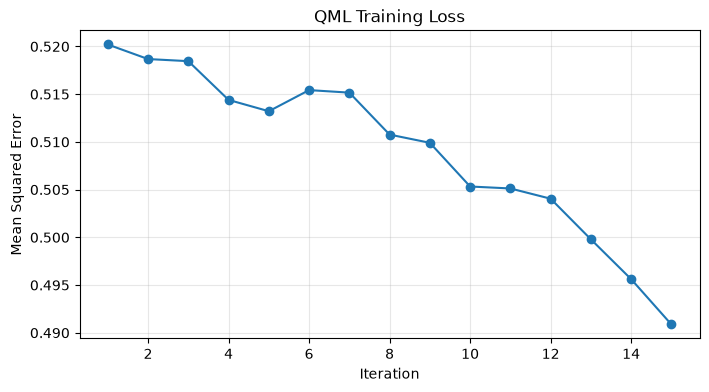

In [26]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(training_history) + 1),
    training_history,
    marker="o"
)

plt.title("QML Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.grid(alpha=0.3)
plt.show()

## 5.6 Evaluate the Trained Quantum Classifier

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Convert trained values into a Qiskit parameter dictionary
trained_parameters = create_parameter_dictionary(
    trained_parameter_values
)

# Evaluate on the separate QML test subset
test_probabilities = []

for index, sample in enumerate(X_qml_test):
    probability = quantum_predict_probability(
        sample,
        trained_parameters,
        shots=256
    )

    test_probabilities.append(probability)

    if (index + 1) % 100 == 0:
        print(f"Evaluated {index + 1}/{len(X_qml_test)} samples")

test_probabilities = np.array(test_probabilities)

# Convert probabilities into binary predictions
test_predictions = (test_probabilities >= 0.5).astype(int)

print("\nEvaluation completed.")

Evaluated 100/1000 samples
Evaluated 200/1000 samples
Evaluated 300/1000 samples
Evaluated 400/1000 samples
Evaluated 500/1000 samples
Evaluated 600/1000 samples
Evaluated 700/1000 samples
Evaluated 800/1000 samples
Evaluated 900/1000 samples
Evaluated 1000/1000 samples

Evaluation completed.


In [28]:
# Calculate evaluation metrics
qml_accuracy = accuracy_score(
    y_qml_test,
    test_predictions
)

qml_precision = precision_score(
    y_qml_test,
    test_predictions,
    zero_division=0
)

qml_recall = recall_score(
    y_qml_test,
    test_predictions,
    zero_division=0
)

qml_f1 = f1_score(
    y_qml_test,
    test_predictions,
    zero_division=0
)

qml_roc_auc = roc_auc_score(
    y_qml_test,
    test_probabilities
)

qml_confusion = confusion_matrix(
    y_qml_test,
    test_predictions
)

print(f"Accuracy:  {qml_accuracy:.4f}")
print(f"Precision: {qml_precision:.4f}")
print(f"Recall:    {qml_recall:.4f}")
print(f"F1-score:  {qml_f1:.4f}")
print(f"ROC-AUC:   {qml_roc_auc:.4f}")

print("\nConfusion matrix:")
print(qml_confusion)

Accuracy:  0.3310
Precision: 0.9286
Recall:    0.0191
F1-score:  0.0374
ROC-AUC:   0.5134

Confusion matrix:
[[318   1]
 [668  13]]


### Preliminary Result Interpretation

The trained QML circuit is evaluated on a separate test subset that was not used during parameter optimization.

The resulting accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix will be compared with the existing classical Random Forest baseline.

Because this experiment uses only four features, 100 training samples, 15 optimization iterations, and a simulator, the result is considered preliminary rather than the final QML performance claim.

## 5.7 Inspect QML Prediction Probabilities

The confusion matrix shows that the model predicts almost every sample as normal. We inspect the probability distribution to determine whether the circuit produces useful separation or simply outputs values close to zero.

In [29]:
print("Minimum attack probability:", test_probabilities.min())
print("Maximum attack probability:", test_probabilities.max())
print("Mean attack probability:", test_probabilities.mean())
print("Median attack probability:", np.median(test_probabilities))

print("\nProbability percentiles:")
print(np.percentile(
    test_probabilities,
    [0, 10, 25, 50, 75, 90, 95, 99, 100]
))

Minimum attack probability: 0.0
Maximum attack probability: 1.0
Mean attack probability: 0.0487109375
Median attack probability: 0.03125

Probability percentiles:
[0.         0.01953125 0.0234375  0.03125    0.04296875 0.0546875
 0.06640625 0.94554687 1.        ]


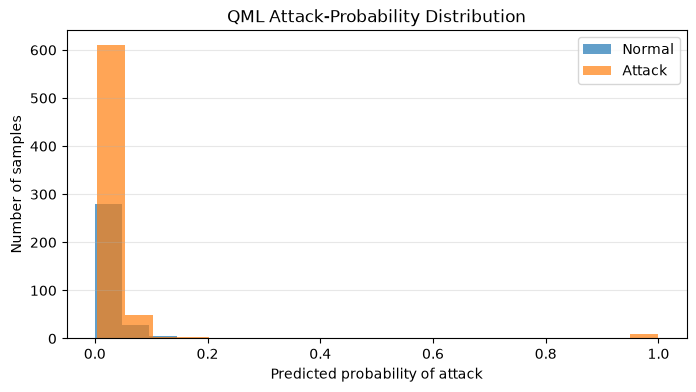

In [30]:
plt.figure(figsize=(8, 4))

plt.hist(
    test_probabilities[y_qml_test == 0],
    bins=20,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    test_probabilities[y_qml_test == 1],
    bins=20,
    alpha=0.7,
    label="Attack"
)

plt.title("QML Attack-Probability Distribution")
plt.xlabel("Predicted probability of attack")
plt.ylabel("Number of samples")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## 5.8 Preliminary QML Baseline Result

The initial variational circuit produced poor classification performance.

The attack-probability distribution is concentrated near zero for both normal and attack samples. This indicates that the circuit has learned only weak class separation and is biased toward the normal class.

The ROC-AUC of approximately 0.51 is close to random classification. Therefore, this circuit configuration is retained as a preliminary baseline and will not be considered the final QML model.

Further experiments will investigate improved feature encoding, circuit structure, parameter optimization, and classification thresholds.

In [31]:
normal_probabilities = test_probabilities[y_qml_test == 0]
attack_probabilities = test_probabilities[y_qml_test == 1]

print(f"Mean normal probability: {normal_probabilities.mean():.4f}")
print(f"Mean attack probability: {attack_probabilities.mean():.4f}")

print(f"Median normal probability: {np.median(normal_probabilities):.4f}")
print(f"Median attack probability: {np.median(attack_probabilities):.4f}")

Mean normal probability: 0.0397
Mean attack probability: 0.0530
Median normal probability: 0.0312
Median attack probability: 0.0312


In [32]:
from sklearn.metrics import accuracy_score

thresholds = np.linspace(0.01, 0.99, 99)

threshold_results = []

for threshold_value in thresholds:
    predictions = (
        test_probabilities >= threshold_value
    ).astype(int)

    threshold_accuracy = accuracy_score(
        y_qml_test,
        predictions
    )

    threshold_results.append(
        (threshold_value, threshold_accuracy)
    )

best_threshold, best_threshold_accuracy = max(
    threshold_results,
    key=lambda item: item[1]
)

print(f"Best diagnostic threshold: {best_threshold:.2f}")
print(f"Accuracy at that threshold: {best_threshold_accuracy:.4f}")

Best diagnostic threshold: 0.01
Accuracy at that threshold: 0.6760


## 6. Conclusion and Transition to the Next Phase

This notebook established the local quantum-computing environment and demonstrated the basic components required for a quantum machine-learning workflow.

The following tasks were completed:

- Verified Qiskit, Qiskit Aer, and Qiskit Machine Learning.
- Demonstrated single-qubit rotations and measurement.
- Demonstrated two-qubit entanglement.
- Encoded selected UNSW-NB15 numerical features into quantum rotation angles.
- Constructed a four-qubit variational quantum circuit.
- Executed the circuit using the Aer simulator.
- Trained a preliminary circuit using a lightweight SPSA optimizer.
- Evaluated the preliminary QML model on a separate test subset.

The preliminary QML model achieved an ROC-AUC of approximately 0.51, indicating that the current small circuit configuration did not learn meaningful attack-versus-normal separation.

This result is treated as an exploratory baseline rather than the final QML model. The experiment confirmed that the quantum workflow operates correctly, while also showing that improved feature selection, circuit architecture, optimization, and training strategy are required.

The completed classical IDS pipeline remains the primary baseline for comparison.

### Next Phase

The next notebook will contain the actual QML classification experiment:

- Use a clearly defined quantum-compatible feature set.
- Train and evaluate multiple QML classifier configurations.
- Use consistent training and testing data.
- Measure accuracy, precision, recall, F1-score, ROC-AUC, false-positive rate, and execution time.
- Compare the best QML model against the existing Random Forest baseline.
- Save the results for use in the final AEGES-Q research comparison.

The next phase will focus on measurable model performance rather than quantum circuit demonstrations.